# C2 — Backward-module ablation (single run)

Fills the **KAN block** of Table C2 in `Results.tex` (`tab: ablation-backward`).
Single seed, one run per variant — the point is to *see the numbers and the
convergence behaviour first*, before committing to a 5-seed sweep.

The forward module is held fixed at KAN `[18,6,6,6]`; only the backward module
changes:

| Row | Forward | Backward | Loss |
|---|---|---|---|
| `kan_star_ce` | KAN `[18,6,6,6]` | none | cross-entropy |
| `logic_kan_star` | KAN `[18,6,6,6]` | logic tensor, six per-class rules | `1 - sat` |
| `h_logic_kan_star` | KAN `[18,6,6,6]` | logic + hierarchy | `1 - sat` |

### Why `[18,6,6,6]` and not `[18,10,6]`

`[18,6,6,6]` is the KAN backbone inside P5's `AttentionKANModel`. Choosing it
here makes the last row **exactly `H-Logic-KAN*`**, and therefore:

| Model | Forward | Backward |
|---|---|---|
| `h_logic_kan_star` (this notebook) | KAN `[18,6,6,6]` | logic + hierarchy |
| Attn-LogiK-Net (full) (from P5) | attention → KAN `[18,6,6,6]` | logic + hierarchy |

These two differ by **exactly the attention encoder**. So the two blocks of
Table C2 can be read *across* as well as *within*, and the same pair doubles as
a clean forward-axis contrast for Table C1 — with no new model needed.

The **attention block** of Table C2 is already done: P5's
`attn_kan_noLTN_2_6.pt` / `attn_kan_2_6.pt`, trained on this same
`logiKNet_train_10000.csv` split. Nothing from P5 is retrained here.

### `flat` vs `hier` — rule sets, NOT architecture

`KAN_WIDTH` is the *forward* module's shape. `flat` / `hier` describe the
*backward* module's rule set and say nothing about network depth:

* **`flat`** — six per-class rules, `∀x labelled c : P(x, c)`. This is ordinary
  supervision restated in fuzzy logic. It encodes **no** relationship between
  classes: class 0 and class 5 are as unrelated as class 0 and class 1.
* **`hier`** — those six, plus one more:
  `∀x ∈ MQTT (labels 0..4) : ¬P(x, Benign)`. This is the only place the class
  **tree** enters training. It groups labels 0–4 into a single LTN variable and
  applies one joint constraint, putting gradient pressure specifically on the
  security-critical error — calling an attack benign — rather than spreading it
  evenly over all confusions. It is not derivable from the six per-class rules.

In `compute_sat_levels` the difference is literally the `if hierarchical:`
branch that appends one `Forall` term.

### Other assumptions — change them in the Config cell

1. **Train split `logiKNet_train_10000.csv`** — the agreed §C protocol, and the
   split P5 already used, so both C2 blocks are protocol-matched.
2. **Seed 42**, matching `AttentionEncoder.ipynb`.
3. **Epoch budget is measured, not assumed.** Each variant trains to its own
   convergence (early stop on loss plateau) and reports `stop_epoch`. Those three
   numbers settle the still-open epoch-budget `[TODO]` in `Results.tex`.

> Requires `ltn`: `pip install LTNtorch` (provides the `ltn` module).

In [21]:
# --- imports & paths ---
import os, sys, json, time
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

# utils.py / MultiKANModel live in P1_structurelevel; eval_metrics.py in P5_attention.
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('../P1_structurelevel'))
sys.path.append(os.path.abspath('../P5_attention'))

from utils import LogitsToPredicate, MultiKANModel, MLP, DataLoader
from kan import KAN
import ltn
import ltn.fuzzy_ops
from eval_metrics import evaluate_run, CHILD_TO_PARENT_6, LABEL_L2_NAMES

# CUDA or CPU, never MPS: LTN Constants stay on CPU while the model moves to the
# GPU, which raises "expected all tensors on the same device".
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [ ]:
# --- Config (edit here) ---
TRAIN_PATH = '../P1_structurelevel/efficiency/input_files/logiKNet_train_10000.csv'
TEST_PATH  = '../P1_structurelevel/efficiency/input_files/logiKNet_test_3994.csv'

X_columns = [
    'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate',
    'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
    'Magnitue', 'Radius', 'Covariance',
]

label_L2_names = {
    0: "MQTT-DDoS-Connect_Flood", 1: "MQTT-DDoS-Publish_Flood",
    2: "MQTT-DoS-Connect_Flood",  3: "MQTT-DoS-Publish_Flood",
    4: "MQTT-Malformed_Data",     5: "Benign",
}
BENIGN_L2 = 5                      # 0..4 -> MQTT (L1=0), 5 -> Benign (L1=1)

IN_FEATURES = len(X_columns)       # 18
N_CLASSES   = len(label_L2_names)  # 6
# Forward module, HELD FIXED across all three rows.
# [18,6,6,6] (two hidden layers of 6) is deliberately chosen to match the KAN
# backbone inside P5's AttentionKANModel. Consequence: the 'Logic + hierarchy'
# row below IS H-Logic-KAN*, and it differs from Attn-LogiK-Net (full) by
# EXACTLY the attention encoder -- so the two blocks of Table C2 become
# readable across, not merely within.
KAN_WIDTH   = [IN_FEATURES, 6, 6, N_CLASSES]

SEED   = 42
LR     = 1e-3
# --- per-variant training budget -------------------------------------------
# This section is a PERFORMANCE comparison, not an epoch-matched fairness test:
# each variant is allowed to train to its own best. Set a generous budget here,
# read the accuracy trace, then come back and set the budget you actually want.
# Any cell can also override with  run_variant(key, epochs=N).
EPOCHS_BY_VARIANT = {
    'kan_star_ce':      600,
    'logic_kan_star':   800,
    'h_logic_kan_star': 800,
}
EPOCHS = 800            # fallback / safety cap

ACC_EVERY  = 100         # evaluate + print TEST accuracy every N epochs
EVAL_EVERY = 100         # print loss/satisfaction every N epochs

# --- optional early stopping on ACCURACY (off by default) -------------------
# Off so you can see the whole curve and choose the stopping point yourself.
# When on: stop if the best test accuracy has not improved by more than
# ACC_MIN_DELTA for ACC_PATIENCE consecutive accuracy checks.
EARLY_STOP    = False
ACC_PATIENCE  = 5        # in units of ACC_EVERY epochs
ACC_MIN_DELTA = 1e-4

# NOTE ON RIGOR: the trace below is TEST accuracy, matching the original
# notebooks. Choosing a stopping epoch from it is technically test-set peeking.
# For the paper, either (a) state that the budget was fixed from a pilot run and
# then held constant across all seeds -- which is what we do, so the seeds are
# still clean -- or (b) carve a validation split off the training data.

# FAST_DEV: train on the small 3994-row file just to confirm everything runs.
# Set False for the real run.
FAST_DEV = False

SAVE_DIR = './saved'
os.makedirs(SAVE_DIR, exist_ok=True)
print('IN_FEATURES =', IN_FEATURES, '| N_CLASSES =', N_CLASSES,
      '| KAN_WIDTH =', KAN_WIDTH)

IN_FEATURES = 18 | N_CLASSES = 6 | KAN_WIDTH = [18, 6, 6, 6]


In [23]:
# --- 1. Read input data ---
if FAST_DEV:
    train_df = pd.read_csv(TEST_PATH)
    test_df  = pd.read_csv(TEST_PATH)
    print('FAST_DEV: training on the 3994-row file (sanity check only)')
else:
    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)

# The CSVs are Git LFS-tracked; without `git lfs pull` they are ~130-byte
# pointer stubs that pandas parses into a 1-column frame.
missing = [c for c in X_columns + ['label_L2'] if c not in train_df.columns]
assert not missing, (f'missing columns in train file: {missing}\n'
                     'If ALL are missing, the CSV is a Git LFS pointer -- run '
                     '`git lfs install && git lfs pull` from the repo root.')

scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_df[X_columns])
test_X_scaled  = scaler.transform(test_df[X_columns])
print('train shape:', train_X_scaled.shape, '| test shape:', test_X_scaled.shape)
print('NaN/Inf in train:', np.isnan(train_X_scaled).any(), np.isinf(train_X_scaled).any())

train_y = train_df['label_L2'].values.astype(int)
test_y  = test_df['label_L2'].values.astype(int)
print('train L2 dist:', np.bincount(train_y, minlength=N_CLASSES))
print('test  L2 dist:', np.bincount(test_y,  minlength=N_CLASSES))

# full-batch loaders. shuffle=False on test keeps the order fixed so that
# predictions stay paired across variants (needed later for McNemar).
train_loader = DataLoader(
    data=torch.tensor(train_X_scaled, dtype=torch.float32, device=device),
    labels=torch.tensor(train_y, dtype=torch.long, device=device),
    batch_size=len(train_df))
test_loader = DataLoader(
    data=torch.tensor(test_X_scaled, dtype=torch.float32, device=device),
    labels=torch.tensor(test_y, dtype=torch.long, device=device),
    batch_size=len(test_df), shuffle=False)

train shape: (10000, 18) | test shape: (3994, 18)
NaN/Inf in train: False False
train L2 dist: [1688 1691 1700 1697 1542 1682]
test  L2 dist: [684 673 639 650 645 703]


In [24]:
# --- 2. LTN setup (connectives, quantifiers, class constants) ---
Not    = ltn.Connective(ltn.fuzzy_ops.NotStandard())
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
SatAgg = ltn.fuzzy_ops.SatAgg()

# Constants are built ON `device`. The original notebooks left them on CPU,
# which works on CPU but breaks the moment the model is on CUDA.
_eye = torch.eye(N_CLASSES, device=device)
l_MQTT_DDoS_Connect_Flood = ltn.Constant(_eye[0])
l_MQTT_DDoS_Publish_Flood = ltn.Constant(_eye[1])
l_MQTT_DoS_Connect_Flood  = ltn.Constant(_eye[2])
l_MQTT_DoS_Publish_Flood  = ltn.Constant(_eye[3])
l_MQTT_Malformed_Data     = ltn.Constant(_eye[4])
l_Benign                  = ltn.Constant(_eye[5])

In [25]:
# --- helpers: satisfaction (flat / hierarchical), accuracy, reliability ---
def compute_sat_levels(loader, P, hierarchical):
    """Six per-class rules; plus the MQTT-is-not-Benign rule if hierarchical.

    This is the ONLY difference between the `logic_kan` and `h_logic_kan` rows.
    """
    sat_level = 0
    for data, labels in loader:
        x_c0 = ltn.Variable("x_c0", data[labels == 0])
        x_c1 = ltn.Variable("x_c1", data[labels == 1])
        x_c2 = ltn.Variable("x_c2", data[labels == 2])
        x_c3 = ltn.Variable("x_c3", data[labels == 3])
        x_c4 = ltn.Variable("x_c4", data[labels == 4])
        x_c5 = ltn.Variable("x_c5", data[labels == 5])
        terms = [
            Forall(x_c0, P(x_c0, l_MQTT_DDoS_Connect_Flood)),
            Forall(x_c1, P(x_c1, l_MQTT_DDoS_Publish_Flood)),
            Forall(x_c2, P(x_c2, l_MQTT_DoS_Connect_Flood)),
            Forall(x_c3, P(x_c3, l_MQTT_DoS_Publish_Flood)),
            Forall(x_c4, P(x_c4, l_MQTT_Malformed_Data)),
            Forall(x_c5, P(x_c5, l_Benign)),
        ]
        if hierarchical:
            x_MQTT = ltn.Variable("x_MQTT", data[labels < BENIGN_L2])
            terms.append(Forall(x_MQTT, Not(P(x_MQTT, l_Benign))))
        sat_level = SatAgg(*terms)
    return sat_level


def compute_accuracy(loader, model):
    total_correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for data, labels in loader:
            preds = torch.argmax(model(data), dim=1)
            total_correct += (preds == labels).sum()
            total += labels.numel()
    return (total_correct.float() / total).item()


def reliable_score(loader, model):
    """The paper's reliability score, w = 0.5. Kept here so this notebook
    reproduces the familiar number; `evaluate_run` computes it too, plus the
    hierarchical F1 it coincides with."""
    score, n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for data, labels in loader:
            preds = torch.argmax(model(data), dim=1)
            for i in range(len(labels)):
                if labels[i] == preds[i]:
                    score += 1.0
                elif labels[i] < BENIGN_L2 and preds[i] < BENIGN_L2:
                    score += 0.5
            n += labels.numel()
    return score / n

In [26]:
# --- 3. The three variants ---
# key -> (display name, backward module)
#   'none'     -> cross-entropy, no LTN
#   'flat'     -> LTN, six per-class rules
#   'hier'     -> LTN, six rules + MQTT-is-not-Benign
# Names carry the paper's '*' suffix because KAN_WIDTH is the DEEP variant
# ([18,6,6,6]); the 'hier' row is therefore H-Logic-KAN* as defined in Sec. V-B.
VARIANTS = {
    'kan_star_ce':      ('KAN* (no logic)', 'none'),
    'logic_kan_star':   ('Logic-KAN*',      'flat'),
    'h_logic_kan_star': ('H-Logic-KAN*',    'hier'),
}


def build_kan():
    """Fresh KAN at the fixed forward-module width, same seed every time."""
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    kan = KAN(width=KAN_WIDTH, grid=5, k=3, seed=SEED, device=device,
              auto_save=False, save_act=False)
    return MultiKANModel(kan).to(device)


def train_variant(key, epochs=None, acc_every=None, early_stop=None,
                  verbose=True):
    """Train one row of Table C2, tracing TEST ACCURACY as it goes.

    epochs     : override the per-variant budget for this call
    acc_every  : how often to evaluate test accuracy
    early_stop : override EARLY_STOP for this call

    Returns (model, P, record). `record['acc_trace']` is the (epoch, accuracy)
    series you use to decide where this variant should stop.
    """
    name, backward = VARIANTS[key]
    epochs = EPOCHS_BY_VARIANT.get(key, EPOCHS) if epochs is None else epochs
    acc_every = ACC_EVERY if acc_every is None else acc_every
    early_stop = EARLY_STOP if early_stop is None else early_stop

    model = build_kan()
    if backward == 'none':
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        P = None
    else:
        P = ltn.Predicate(LogitsToPredicate(model))
        optimizer = torch.optim.Adam(P.parameters(), lr=LR)
    hier = (backward == 'hier')

    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f'--- {name}  (backward: {backward}, {n_par} params, '
              f'budget {epochs} epochs) ---')
        print(f"{'epoch':>7}{'loss':>10}{'train sat':>12}{'test acc':>10}"
              f"{'best acc':>10}{'elapsed':>9}")

    hist_loss, hist_sat = [], []
    acc_epochs, acc_values = [], []
    best_acc, best_epoch, stale = -1.0, -1, 0
    stop_epoch = epochs - 1
    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        if backward == 'none':
            loss = criterion(model(train_loader.data, training=True),
                             train_loader.labels)
            sat_v = float('nan')
        else:
            sat = compute_sat_levels(train_loader, P, hier)
            loss = 1. - sat
            sat_v = sat.item()
        loss.backward()
        optimizer.step()
        hist_loss.append(loss.item())
        hist_sat.append(sat_v)

        if epoch % acc_every == 0 or epoch == epochs - 1:
            acc = compute_accuracy(test_loader, model)
            acc_epochs.append(epoch)
            acc_values.append(acc)
            improved = acc > best_acc + ACC_MIN_DELTA
            if acc > best_acc:
                best_acc, best_epoch = acc, epoch
            stale = 0 if improved else stale + 1
            if verbose:
                st = '   --' if np.isnan(sat_v) else f'{sat_v:>12.4f}'
                print(f'{epoch:>7}{loss.item():>10.4f}{st}{acc:>10.4f}'
                      f'{best_acc:>10.4f}{time.time()-t_start:>8.0f}s')
            if early_stop and stale >= ACC_PATIENCE:
                stop_epoch = epoch
                if verbose:
                    print(f'  early stop: no accuracy gain > {ACC_MIN_DELTA:g} '
                          f'for {ACC_PATIENCE} checks')
                break

    elapsed = time.time() - t_start

    # "where should this variant stop?" -- first epoch reaching within
    # PLATEAU_TOL of the best accuracy seen. This is the number to put in
    # EPOCHS_BY_VARIANT, not the argmax, which is noise-sensitive.
    PLATEAU_TOL = 0.002
    reach = [e for e, a in zip(acc_epochs, acc_values)
             if a >= best_acc - PLATEAU_TOL]
    plateau_epoch = reach[0] if reach else stop_epoch

    record = {'key': key, 'name': name, 'backward': backward,
              'epochs_run': int(len(hist_loss)), 'stop_epoch': int(stop_epoch),
              'params': int(n_par), 'seconds': round(elapsed, 1),
              'best_acc': float(best_acc), 'best_epoch': int(best_epoch),
              'plateau_epoch': int(plateau_epoch), 'plateau_tol': PLATEAU_TOL,
              'acc_epochs': acc_epochs, 'acc_values': acc_values,
              'hist_loss': hist_loss, 'hist_sat': hist_sat}

    if verbose:
        print(f'\n  best test acc {best_acc:.4f} @ epoch {best_epoch}')
        print(f'  first within {PLATEAU_TOL:g} of best @ epoch {plateau_epoch}'
              f'   <-- suggested budget for this variant')
        if best_epoch >= len(hist_loss) - acc_every:
            print('  WARNING: best accuracy is at the END of the run -- still '
                  'improving, raise this variant\'s budget.')
        print(f'  done in {elapsed:.0f}s\n')
    return model, P, record


# --- storage shared by the three per-variant cells below ---
models, preds_P, records, results = {}, {}, {}, {}


def run_variant(key, epochs=None, **kw):
    """Train + evaluate ONE variant and store it. Safe to re-run alone."""
    model, P, rec = train_variant(key, epochs=epochs, **kw)
    res = evaluate_run(model, test_loader, n_classes=N_CLASSES, device=device,
                       child_to_parent=CHILD_TO_PARENT_6, partial=0.5)
    # satisfaction is only defined for the LTN-trained rows
    res['test_sat'] = (float('nan') if P is None else
                       compute_sat_levels(test_loader, P,
                                          rec['backward'] == 'hier').item())
    models[key], preds_P[key], records[key], results[key] = model, P, rec, res
    print(f"[{rec['name']}] final acc {res['accuracy']:.4f} | "
          f"macroF1 {res['macro_f1']:.4f} | reliab {res['reliability']:.4f} | "
          f"sat {res['test_sat']:.4f}")
    return rec, res


### Run each variant in its own cell

One cell per row, so each can be run, inspected and re-tuned on its own without
retraining the others. Each stores into the shared `records` / `results` dicts,
so the summary cells further down work regardless of the order you run these in
(or if you re-run just one).

Read `stop_epoch` off each. Those three numbers settle the epoch-budget `[TODO]`
in the §C protocol paragraph of `Results.tex`.

If a variant stops while its curve is clearly still falling, raise `MIN_EPOCHS`
or lower `REL_TOL` in the Config cell and re-run **only that cell**.

#### Row 1 — `kan_star_ce`: KAN\*, no logic (cross-entropy)

In [34]:
rec, res = run_variant('kan_star_ce')

--- KAN* (no logic)  (backward: none, 2520 params, budget 800 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    1.7806   --    0.1843    0.1843       0s
    100    1.3527   --    0.5165    0.5165       4s
    200    0.7902   --    0.6725    0.6725       8s
    300    0.6402   --    0.7421    0.7421      12s
    400    0.5687   --    0.7541    0.7541      16s
    500    0.5283   --    0.7666    0.7666      20s
    600    0.4908   --    0.7822    0.7822      24s
    700    0.4561   --    0.7929    0.7929      28s
    799    0.4312   --    0.7999    0.7999      32s

  best test acc 0.7999 @ epoch 799
  first within 0.002 of best @ epoch 799   <-- suggested budget for this variant
  done in 32s

[KAN* (no logic)] final acc 0.7999 | macroF1 0.7995 | reliab 0.8772 | sat nan


#### Row 2 — `logic_kan_star`: KAN\* + logic tensor (six per-class rules)

In [28]:
rec, res = run_variant('logic_kan_star')

--- Logic-KAN*  (backward: flat, 2520 params, budget 800 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    0.8308      0.1692    0.1838    0.1838       0s
    100    0.7232      0.2768    0.5005    0.5005      10s
    200    0.5298      0.4702    0.7018    0.7018      20s
    300    0.4515      0.5485    0.7536    0.7536      30s
    400    0.4176      0.5824    0.7621    0.7621      40s
    500    0.3915      0.6085    0.7869    0.7869      50s
    600    0.3740      0.6260    0.7989    0.7989      61s
    700    0.3648      0.6352    0.8017    0.8017      71s
    799    0.3579      0.6421    0.8065    0.8065      81s

  best test acc 0.8065 @ epoch 799
  first within 0.002 of best @ epoch 799   <-- suggested budget for this variant
  done in 81s

[Logic-KAN*] final acc 0.8065 | macroF1 0.8063 | reliab 0.8835 | sat 0.6225


#### Row 3 — `h_logic_kan_star`: KAN\* + logic + hierarchy

Identical to Row 2 except `compute_sat_levels` appends `Forall(x_MQTT, Not(P(x_MQTT, l_Benign)))`.

In [29]:
rec, res = run_variant('h_logic_kan_star')

--- H-Logic-KAN*  (backward: hier, 2520 params, budget 800 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    0.7718      0.2282    0.1813    0.1813       0s
    100    0.6749      0.3251    0.4980    0.4980      14s
    200    0.4894      0.5106    0.7166    0.7166      28s
    300    0.4188      0.5812    0.7514    0.7514      42s
    400    0.3889      0.6111    0.7621    0.7621      56s
    500    0.3660      0.6340    0.7847    0.7847      70s
    600    0.3492      0.6508    0.7952    0.7952      84s
    700    0.3413      0.6587    0.8007    0.8007      98s
    799    0.3353      0.6647    0.8025    0.8025     112s

  best test acc 0.8025 @ epoch 799
  first within 0.002 of best @ epoch 700   <-- suggested budget for this variant
  done in 112s

[H-Logic-KAN*] final acc 0.8025 | macroF1 0.8024 | reliab 0.8788 | sat 0.6454


### Table C2 — KAN block, single run

Same column order as `tab: ablation-backward` in `Results.tex`, so the numbers
can be read straight across. These are **single-run** values; the paper table
needs mean ± std over seeds.

In [30]:
BACKWARD_LABEL = {'none': 'None (cross-entropy)',
                  'flat': 'Logic tensor',
                  'hier': 'Logic + hierarchy'}

cols = [('accuracy', 'Acc.'), ('macro_f1', 'Macro-F1'),
        ('macro_recall', 'Macro Rec.'), ('macro_fpr', 'Macro FPR'),
        ('macro_auroc', 'AUROC')]

print('Table C2 (KAN block, single run, seed %d)' % SEED)
print('-' * 104)
print(f"{'Backward module':<22}{'Model':<17}" + ''.join(f'{h:>13}' for _, h in cols)
      + f"{'Sat.':>10}{'stop_ep':>9}")
print('-' * 104)
for key in VARIANTS:
    r, res = records[key], results[key]
    row = f"{BACKWARD_LABEL[r['backward']]:<22}{r['name']:<17}"
    row += ''.join(f'{res[m]:>13.4f}' for m, _ in cols)
    row += ('         --' if np.isnan(res['test_sat']) else f"{res['test_sat']:>10.4f}")
    row += f"{r['stop_epoch']:>9}"
    print(row)
print('-' * 104)

print('\nHierarchical + calibration (feeds Table C3):')
print(f"{'Model':<17}{'R(0.5)':>10}{'Hier-F1':>10}{'ECE':>10}{'Brier':>10}")
for key in VARIANTS:
    res = results[key]
    print(f"{records[key]['name']:<17}{res['reliability']:>10.4f}"
          f"{res['hierarchical_f1']:>10.4f}{res['ece']:>10.4f}{res['brier']:>10.4f}")
print('\nnote: R(0.5) and Hier-F1 are the same statistic for this single-parent')
print('      two-level hierarchy -- they should match exactly.')

print('\nPer-class recall:')
print(f"{'class':<28}" + ''.join(f"{records[k]['name']:>17}" for k in VARIANTS))
for c in range(N_CLASSES):
    print(f'{c} {LABEL_L2_NAMES[c]:<26}' +
          ''.join(f"{results[k]['per_class_recall'][c]:>17.4f}" for k in VARIANTS))

print('\n>>> epoch budgets observed:',
      {records[k]['name']: records[k]['stop_epoch'] for k in VARIANTS})
print('    (these settle the [TODO] epoch-budget decision in Results.tex)')

Table C2 (KAN block, single run, seed 42)
--------------------------------------------------------------------------------------------------------
Backward module       Model                     Acc.     Macro-F1   Macro Rec.    Macro FPR        AUROC      Sat.  stop_ep
--------------------------------------------------------------------------------------------------------
None (cross-entropy)  KAN* (no logic)         0.7661       0.7652       0.7660       0.0468       0.9620         --      499
Logic tensor          Logic-KAN*              0.8065       0.8063       0.8075       0.0386       0.9683    0.6225      799
Logic + hierarchy     H-Logic-KAN*            0.8025       0.8024       0.8040       0.0394       0.9689    0.6454      799
--------------------------------------------------------------------------------------------------------

Hierarchical + calibration (feeds Table C3):
Model                R(0.5)   Hier-F1       ECE     Brier
KAN* (no logic)      0.8464    0.8464    0

### Convergence curves

Sanity check that early stopping fired at a real plateau rather than a flat
stretch mid-descent. If a curve is still visibly falling at `stop_epoch`,
raise `MIN_EPOCHS` or lower `REL_TOL` in the Config cell and re-run that variant's cell.

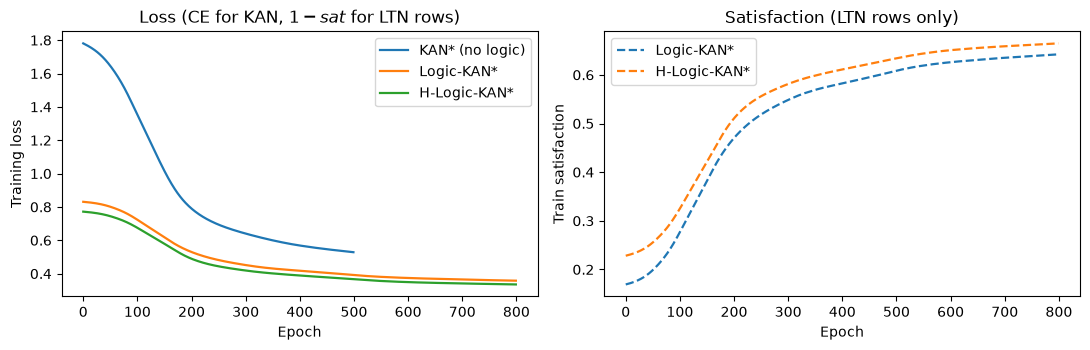

In [31]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for key in VARIANTS:
    r = records[key]
    axs[0].plot(r['hist_loss'], label=r['name'], linewidth=1.6)
    if not np.all(np.isnan(r['hist_sat'])):
        axs[1].plot(r['hist_sat'], label=r['name'], linewidth=1.6, linestyle='--')
axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Training loss')
axs[0].set_title('Loss (CE for KAN, $1-sat$ for LTN rows)')
axs[0].legend()
axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Train satisfaction')
axs[1].set_title('Satisfaction (LTN rows only)')
axs[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'c2_convergence.png'), dpi=150,
            bbox_inches='tight')
plt.show()

### Save checkpoints + results

Checkpoints are state_dict-based: pykan's `Symbolic_KANLayer` holds lambdas that
cannot be pickled, so `torch.save(model, ...)` would fail. Rebuild and
`load_state_dict` to reload.

In [32]:
out = {'seed': SEED, 'train_path': TRAIN_PATH, 'test_path': TEST_PATH,
       'kan_width': KAN_WIDTH, 'lr': LR, 'fast_dev': FAST_DEV, 'variants': {}}

for key in VARIANTS:
    r, res = records[key], results[key]
    ckpt_path = os.path.join(SAVE_DIR, f'{key}_2_6.pt')
    torch.save({
        'model_state': models[key].state_dict(),
        'variant': key, 'backward': r['backward'],
        'config': {'IN_FEATURES': IN_FEATURES, 'N_CLASSES': N_CLASSES,
                   'KAN_WIDTH': KAN_WIDTH, 'SEED': SEED,
                   'X_columns': X_columns, 'label_L2_names': label_L2_names,
                   'BENIGN_L2': BENIGN_L2},
        'scaler_mean': scaler.mean_, 'scaler_scale': scaler.scale_,
        'history': {'loss': r['hist_loss'], 'sat': r['hist_sat']},
        'stop_epoch': r['stop_epoch'],
        'metrics': {k: v for k, v in res.items() if not k.startswith('_')},
    }, ckpt_path)

    out['variants'][key] = {
        'name': r['name'], 'backward': r['backward'],
        'stop_epoch': r['stop_epoch'], 'params': r['params'],
        'seconds': r['seconds'],
        'metrics': {k: v for k, v in res.items()
                    if not k.startswith('_') and k != 'per_class_recall'},
        'per_class_recall': {str(c): float(v)
                             for c, v in res['per_class_recall'].items()},
    }
    print('saved ->', ckpt_path)

res_path = os.path.join(SAVE_DIR, 'c2_single_run.json')
with open(res_path, 'w') as f:
    json.dump(out, f, indent=2, default=float)
print('saved ->', res_path)

saved -> ./saved/kan_star_ce_2_6.pt
saved -> ./saved/logic_kan_star_2_6.pt
saved -> ./saved/h_logic_kan_star_2_6.pt
saved -> ./saved/c2_single_run.json


## Next steps

1. **Check the three `stop_epoch` values.** They decide the epoch budget in the
   §C protocol paragraph of `Results.tex` (currently `[TODO]`). If they are close
   to each other, a single fixed budget at the max is defensible and keeps the
   rows epoch-matched; if they differ a lot, use per-variant budgets and say so.
2. **Check the ordering makes sense** before scaling up — does adding the logic
   tensor, and then the hierarchy rule, move the metrics the way the paper claims?
   If not, that is worth understanding now rather than after a 5-seed sweep.
3. **Then** run the multi-seed version to get mean ± std and the paired tests for
   the actual table.

### Reload a checkpoint

```python
import torch
from utils import MultiKANModel
from kan import KAN

ckpt = torch.load('./saved/h_logic_kan_2_6.pt', map_location=device,
                  weights_only=False)
cfg = ckpt['config']
kan = KAN(width=cfg['KAN_WIDTH'], grid=5, k=3, seed=cfg['SEED'], device=device,
          auto_save=False, save_act=False)
model = MultiKANModel(kan).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

# re-apply the saved scaler to raw features before inference:
#   X = (X_raw - ckpt['scaler_mean']) / ckpt['scaler_scale']
```